### Load relevant libraries

In [113]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, log_loss, accuracy_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

### Read in the data

In [114]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/March Madness 2026/2026 Data'
os.chdir(path)

In [115]:
df_all = pd.read_csv('dyad_matchups.csv', sep=',', index_col=None)
games_to_pred = pd.read_csv('games_to_predict.csv', sep=',', index_col=None)
team_a_stats = pd.read_csv('team_a_stats.csv', sep=',', index_col=None)
team_b_stats = pd.read_csv('team_b_stats.csv', sep=',', index_col=None)

### Prep the Data

In [116]:
# create a list including the desired explanatory variables
column_names = df_all.columns.values.tolist()

with pd.option_context('display.max_columns', None):
    print(df_all[column_names].head()), df_all[column_names].shape

   Season  team_a  team_b  team_a_win  top_a  mid_a  bot_a  intourney_a  \
0    2022    1231    1461           1      0      1      0          1.0   
1    2022    1394    1411           0      1      0      0          1.0   
2    2022    1323    1353           1      0      0      1          1.0   
3    2022    1136    1460           0      0      1      0          1.0   
4    2022    1116    1436           1      1      0      0          1.0   

   top_b  mid_b  bot_b  intourney_b  efg_diff   sa_diff   pt_diff  rank_diff  \
0      1      0      0          1.0  0.123279 -0.466673 -0.083709          3   
1      1      0      0          1.0 -0.223596  0.399081 -0.134725          0   
2      0      1      0          1.0  0.953422  0.732658  0.378520          4   
3      0      0      1          1.0 -1.008504  1.952189 -0.062424         -4   
4      1      0      0          1.0 -1.947198  0.317117 -0.739062          1   

   winsbefore_diff  winsafter_diff  clutch_diff  close_diff  grit_di

In [117]:
# Drop unnecessary variables: 
column_names = np.delete(column_names, [0, 1, 2, 3, 6, 7, 10, 11])

with pd.option_context('display.max_columns', None):
    print(df_all[column_names].head()), df_all[column_names].shape

   top_a  mid_a  top_b  mid_b  efg_diff   sa_diff   pt_diff  rank_diff  \
0      0      1      1      0  0.123279 -0.466673 -0.083709          3   
1      1      0      1      0 -0.223596  0.399081 -0.134725          0   
2      0      0      0      1  0.953422  0.732658  0.378520          4   
3      0      1      0      0 -1.008504  1.952189 -0.062424         -4   
4      1      0      1      0 -1.947198  0.317117 -0.739062          1   

   winsbefore_diff  winsafter_diff  clutch_diff  close_diff  grit_diff  \
0        -0.672530       -0.449176    -1.839140    0.211692  -2.412397   
1         0.472988       -0.661514     0.916100   -1.774185  -2.412397   
2        -0.174259        0.757985     0.864850   -0.686781   1.206199   
3         0.015918        0.898353     0.971621   -1.419348  -1.182384   
4         0.248319       -1.065773     0.000000    0.584674   2.412397   

   has_ot_diff  off_diff  def_diff  ast_diff   to_diff  stl_diff  blk_diff  \
0    -1.356835 -0.058910  0.0411

###### Dropped:
> ###### Season, team_a, team_b as these aren't predictors
> ###### team_a_win as this is our dependent variable
> ###### bot_a, bot_b to avoid multicollinearity
> ###### intourney_a, intourney_b since this is accounted for in winpercintourney

In [118]:
# Check for NaNs
print(df_all[column_names].isnull().sum())

# Set all NaN to 0
df_vars = df_all[column_names].fillna(0)

# Check for NaN's
# print(df_vars.isnull().sum())

top_a                    0
mid_a                    0
top_b                    0
mid_b                    0
efg_diff                 0
sa_diff                  0
pt_diff                  0
rank_diff                0
winsbefore_diff          0
winsafter_diff           0
clutch_diff              0
close_diff               0
grit_diff                0
has_ot_diff              0
off_diff                 0
def_diff                 0
ast_diff                 0
to_diff                  0
stl_diff                 0
blk_diff                 0
or_diff                  0
dr_diff                  0
3m_diff                  0
3a_diff                  0
seed_diff                0
conf_diff                0
winpercintourney_diff    0
dtype: int64


In [119]:
display(df_vars.head())

,top_a,mid_a,top_b,mid_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,seed_diff,conf_diff,winpercintourney_diff
0,0,1,1,0,0.123279,-0.466673,-0.083709,3,-0.672530,-0.449176,-1.839140,0.211692,-2.412397,-1.356835,-0.058910,0.041184,2.038143,0.307274,1.256320,2.806270,0.301169,-0.262428,-0.871038,-1.216128,0.0,6.0,0.500000
1,1,0,1,0,-0.223596,0.399081,-0.134725,0,0.472988,-0.661514,0.916100,-1.774185,-2.412397,-0.023727,0.684506,0.910136,1.404097,-0.153717,1.678516,-3.281965,0.311260,-1.045113,0.082365,0.127126,0.0,2.0,-0.500000
2,0,0,0,1,0.953422,0.732658,0.378520,4,-0.174259,0.757985,0.864850,-0.686781,1.206199,0.000000,0.608846,0.184594,-0.404406,-0.540938,-1.395293,-2.023982,-1.612410,1.011400,1.853222,1.517316,0.0,-3.0,0.666667
3,0,1,0,0,-1.008504,1.952189,-0.062424,-4,0.015918,0.898353,0.971621,-1.419348,-1.182384,1.426481,0.193547,0.287855,-0.221859,0.411605,0.371699,1.275345,0.822259,1.691796,1.233609,2.027859,0.0,-3.0,-0.500000
4,1,0,1,0,-1.947198,0.317117,-0.739062,1,0.248319,-1.065773,0.000000,0.584674,2.412397,1.269149,0.330585,1.284756,-0.487217,1.177091,1.619460,1.713927,2.150837,-0.307921,-1.512763,-0.816450,9.0,24.0,0.750000


### Logistic Regression

In [120]:
### Define y and X
y = df_all['team_a_win'].astype(bool)
X = df_vars

# Check for and remove columns with zero variance
X_var = X.var()
zero_var_cols = X_var[X_var == 0].index
X = X.drop(columns=zero_var_cols, errors='ignore')

# Add intercept
X = sm.add_constant(X)

In [121]:
### Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [122]:
### Run the model
logit_model=sm.Logit(y_train,X_train)
result=logit_model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.469765
         Iterations 7
                           Results: Logit
Model:                Logit             Method:            MLE       
Dependent Variable:   team_a_win        Pseudo R-squared:  0.322     
Date:                 2026-03-16 12:31  AIC:               29008.5670
No. Observations:     30816             BIC:               29241.9691
Df Model:             27                Log-Likelihood:    -14476.   
Df Residuals:         30788             LL-Null:           -21360.   
Converged:            1.0000            LLR p-value:       0.0000    
No. Iterations:       7.0000            Scale:             1.0000    
---------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
---------------------------------------------------------------------
const                  0.0212   0.0199  1.0643 0.2872 -0.0179  0.0603
top_a           

### Evaluating model on Test Data

In [123]:
### Predict on the test data
# Predicted probabilities
y_pred_prob = result.predict(X_test)

# Convert probabilities to 0/1 predictions for accuracy
y_pred = (y_pred_prob > 0.5).astype(int)

#### Accuracy, Log Loss, ROC AUC

In [124]:
# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_pred_prob))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.7735291890664042
Log Loss: 0.46625765478828723
ROC AUC: 0.8576483944440776


##### ~77% games are correctly predicted with a 0.5 cutoff
##### 0.47 Log Loss suggests good calibration (< 0.5); method penalizes wrong predictions heavily
##### 0.86 ROC AUC is closer to 1.0 (perfect separation) than 0.5 (random guessing)

In [125]:
# Brier score for Kaggle
print("Brier Score:", brier_score_loss(y_test, y_pred_prob))

Brier Score: 0.15399944867249485


In [126]:
# Confusion matrix and Classification Report

confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)
# 5046 True Negatives; 1546 False Negatives
# 5170 True Positives; 1445 False Positives


print(classification_report(y_test, y_pred))
# 77-78% Precision: True Positives / TP + FP
# 77-78% Recall: True Positives / TP + FN
# 77-78% F1-Score: 2 * (Precision * Recall) / (Precision + Recall)

[[5046 1546]
 [1445 5170]]
              precision    recall  f1-score   support

       False       0.78      0.77      0.77      6592
        True       0.77      0.78      0.78      6615

    accuracy                           0.77     13207
   macro avg       0.77      0.77      0.77     13207
weighted avg       0.77      0.77      0.77     13207



##### False negatives are balanced with false positives, meaning model isn't biased toward over-predicting wins or losses; no systematic over/under-confidence
> ##### 1445 False Negatives / 1546 False Positives

##### Balanced across False/True classes, no major bias toward predicting favorites incorrectly
> ##### 0.77-0.78 score across metrics for both False and True

##### F1 around 0.77-0.78 aligns with the previously determined accuracy score

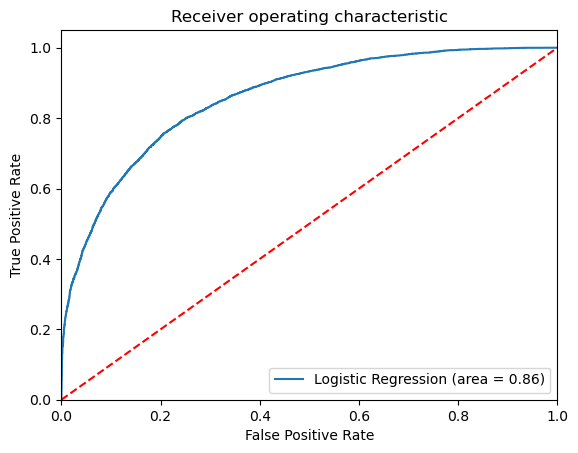

In [127]:
### PLotting the ROC AUC

# ROC AUC
logit_roc_auc = roc_auc_score(y_test, y_pred_prob)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

#### Calibration Plot

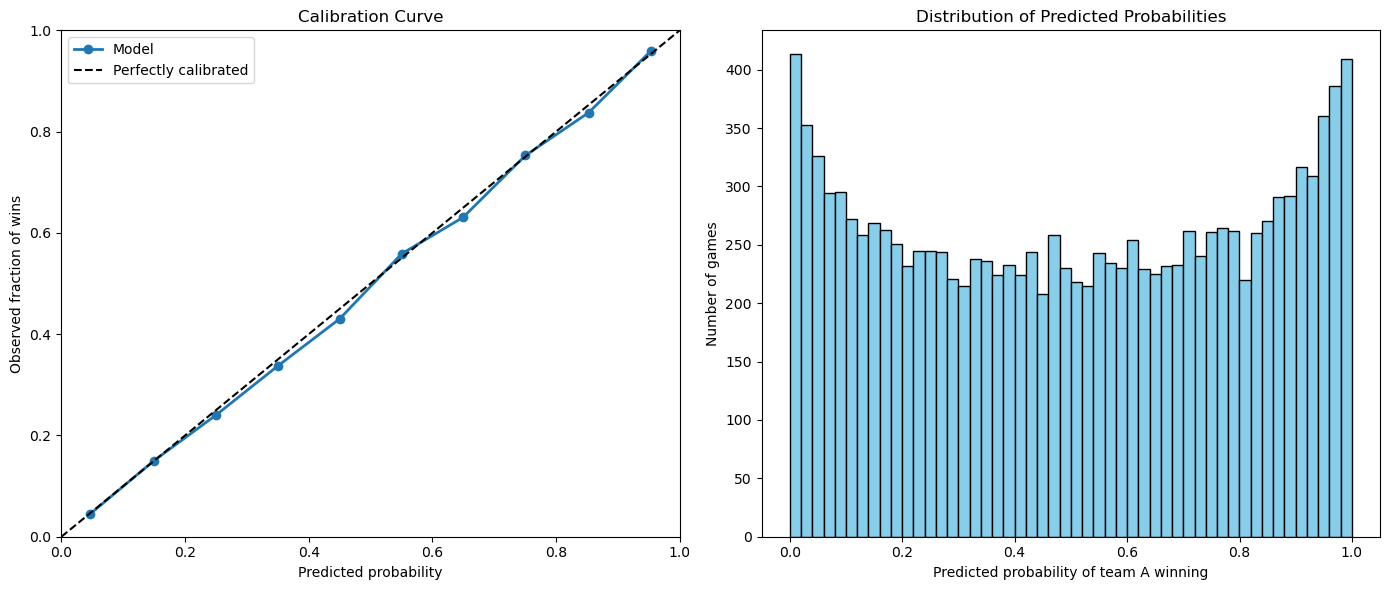

In [128]:
# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

# Create figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Calibration Curve
ax[0].plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
ax[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax[0].set_xlabel('Predicted probability')
ax[0].set_ylabel('Observed fraction of wins')
ax[0].set_title('Calibration Curve')
ax[0].legend()
ax[0].set_xlim([0, 1])
ax[0].set_ylim([0, 1])

# Distribution of predicted probabilities
ax[1].hist(y_pred_prob, bins=50, color='skyblue', edgecolor='k')
ax[1].set_xlabel('Predicted probability of team A winning')
ax[1].set_ylabel('Number of games')
ax[1].set_title('Distribution of Predicted Probabilities')

plt.tight_layout()
plt.show()

##### Interpreting the Calibration Curve:
> ##### Points near diagonal means probabilities match actual outcomes
> ##### Points below: model overconfident
> ##### Points above: model is underconfident

##### Interpreting the Probability Distribution
> ##### Spread between 0.1 to 0.9 means model is making meaningful distinctions between favorites and underdogs
> ##### Clustering around 0.5 means model is indecisive

#####

### Print the results

In [129]:
SampleSubmission = pd.read_csv("SampleSubmissionStage2.csv", sep=',', index_col=None)
team_a_2026 = pd.read_csv("team_a_2026.csv", sep=',', index_col=None)
team_b_2026 = pd.read_csv("team_b_2026.csv", sep=',', index_col=None)

##### Remake the dataset for 2026 data

In [130]:
submission = pd.concat([SampleSubmission['ID'], SampleSubmission['ID'].str.split('_', expand=True).rename(
    columns={0:'season', 1:'team_a', 2:'team_b'})], axis=1)
submission.head()

,ID,season,team_a,team_b
0,2026_1101_1102,2026,1101,1102
1,2026_1101_1103,2026,1101,1103
2,2026_1101_1104,2026,1101,1104
3,2026_1101_1105,2026,1101,1105
4,2026_1101_1106,2026,1101,1106


In [131]:
submission[['team_a', 'team_b', 'season']] = submission[['team_a','team_b','season']].astype(int)

In [132]:
pred1 = pd.merge(submission, team_a_2026, how='left', left_on=['season','team_a'], right_on=['Season','team_a']).drop(['Season'], axis=1)
pred2 = pd.merge(pred1, team_b_2026, how='left', left_on=['team_b','season'], right_on=['team_b','Season']).drop(['Season'], axis=1)

In [133]:
pred2.head()

,ID,season,team_a,team_b,conf_a,z.efg_a,z.sa_a,z.pt_a,rank_a,top_a,mid_a,bot_a,z.winsbefore_a,z.winsafter_a,z.clutch_a,z.close_a,z.grit_a,z.has_ot_a,z.off_a,z.def_a,z.ast_a,z.to_a,z.stl_a,z.blk_a,z.or_a,z.dr_a,z.3m_a,z.3a_a,seed_strength_a,M_W_a,conf_strength_a,winpercintourney_a,conf_b,z.efg_b,z.sa_b,z.pt_b,rank_b,top_b,mid_b,bot_b,z.winsbefore_b,z.winsafter_b,z.clutch_b,z.close_b,z.grit_b,z.has_ot_b,z.off_b,z.def_b,z.ast_b,z.to_b,z.stl_b,z.blk_b,z.or_b,z.dr_b,z.3m_b,z.3a_b,seed_strength_b,M_W_b,conf_strength_b,winpercintourney_b
0,2026_1101_1102,2026,1101,1102,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mwc,-0.175115,-1.203686,-2.076803,20,0,0,1,-1.763332,-1.976930,-1.203073,-1.285651,0.00000,-1.178771,-1.018115,1.379356,-0.504111,0.085482,-0.970406,-0.878070,-1.941526,-1.012617,-0.245519,-0.007985,17.0,M,26.0,0.000000
1,2026_1101_1103,2026,1101,1103,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mac,2.088606,1.858487,1.446969,4,0,1,0,1.316575,2.119790,0.512228,-0.948143,0.00000,-1.178771,2.058478,0.616427,2.015763,-0.916825,-0.042117,-0.357421,0.220382,1.026064,2.289566,1.692553,5.0,M,16.0,0.000000
2,2026_1101_1104,2026,1101,1104,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,sec,1.132784,3.593371,0.973787,11,0,0,1,1.010385,1.095610,1.247357,0.064381,1.25203,-0.451174,2.646483,1.889455,1.244654,-1.294037,-0.506262,1.920422,0.580700,2.029960,3.329134,3.447199,13.0,M,31.0,0.554167
3,2026_1101_1105,2026,1101,1105,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,0.404848,-1.220059,-0.259354,3,1,0,0,-0.093441,0.299025,0.022142,-0.475631,1.25203,-0.402667,0.175851,0.526532,-0.910779,-0.904610,-0.641934,-0.504938,-0.853365,-0.154929,-0.302665,-0.752100,17.0,M,4.0,0.000000
4,2026_1101_1106,2026,1101,1106,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,-0.275941,0.606209,-0.668243,16,0,0,1,-1.117280,-0.440660,-0.794668,-0.545311,0.00000,-1.178771,0.193995,1.053695,-0.686672,-0.210030,0.312613,0.578909,0.714367,-0.350494,0.235141,0.433855,17.0,M,4.0,0.125000


In [134]:
### Calculate differences
pred2['efg_diff'] = pred2['z.efg_a'] - pred2['z.efg_b']
pred2['sa_diff'] = pred2['z.sa_a'] - pred2['z.sa_b']
pred2['pt_diff'] = pred2['z.pt_a'] - pred2['z.pt_b']
pred2['rank_diff'] = pred2['rank_a'] - pred2['rank_b']
pred2['winsbefore_diff'] = pred2['z.winsbefore_a'] - pred2['z.winsbefore_b']
pred2['winsafter_diff'] = pred2['z.winsafter_a'] - pred2['z.winsafter_b']
pred2['clutch_diff'] = pred2['z.clutch_a'] - pred2['z.clutch_b']
pred2['close_diff'] = pred2['z.close_a'] - pred2['z.close_b']
pred2['grit_diff'] = pred2['z.grit_a'] - pred2['z.grit_b']
pred2['has_ot_diff'] = pred2['z.has_ot_a'] - pred2['z.has_ot_b']
pred2['off_diff'] = pred2['z.off_a'] - pred2['z.off_b']
pred2['def_diff'] = pred2['z.def_a'] - pred2['z.def_b']
pred2['ast_diff'] = pred2['z.ast_a'] - pred2['z.ast_b']
pred2['to_diff'] = pred2['z.to_a'] - pred2['z.to_b']
pred2['stl_diff'] = pred2['z.stl_a'] - pred2['z.stl_b']
pred2['blk_diff'] = pred2['z.blk_a'] - pred2['z.blk_b']
pred2['or_diff'] = pred2['z.or_a'] - pred2['z.or_b']
pred2['dr_diff'] = pred2['z.dr_a'] - pred2['z.dr_b']
pred2['3m_diff'] = pred2['z.3m_a'] - pred2['z.3m_b']
pred2['3a_diff'] = pred2['z.3a_a'] - pred2['z.3a_b']
pred2['winpercintourney_diff'] = pred2['winpercintourney_a'] - pred2['winpercintourney_b']
pred2['seed_diff'] = pred2['seed_strength_a'] - pred2['seed_strength_b']
pred2['conf_diff'] = pred2['conf_strength_a'] - pred2['conf_strength_b']

In [135]:
pred2.head()

,ID,season,team_a,team_b,conf_a,z.efg_a,z.sa_a,z.pt_a,rank_a,top_a,mid_a,bot_a,z.winsbefore_a,z.winsafter_a,z.clutch_a,z.close_a,z.grit_a,z.has_ot_a,z.off_a,z.def_a,z.ast_a,z.to_a,z.stl_a,z.blk_a,z.or_a,z.dr_a,z.3m_a,z.3a_a,seed_strength_a,M_W_a,conf_strength_a,winpercintourney_a,conf_b,z.efg_b,z.sa_b,z.pt_b,rank_b,top_b,mid_b,bot_b,z.winsbefore_b,z.winsafter_b,z.clutch_b,z.close_b,z.grit_b,z.has_ot_b,z.off_b,z.def_b,z.ast_b,z.to_b,z.stl_b,z.blk_b,z.or_b,z.dr_b,z.3m_b,z.3a_b,seed_strength_b,M_W_b,conf_strength_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff
0,2026_1101_1102,2026,1101,1102,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mwc,-0.175115,-1.203686,-2.076803,20,0,0,1,-1.763332,-1.976930,-1.203073,-1.285651,0.00000,-1.178771,-1.018115,1.379356,-0.504111,0.085482,-0.970406,-0.878070,-1.941526,-1.012617,-0.245519,-0.007985,17.0,M,26.0,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0
1,2026_1101_1103,2026,1101,1103,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,mac,2.088606,1.858487,1.446969,4,0,1,0,1.316575,2.119790,0.512228,-0.948143,0.00000,-1.178771,2.058478,0.616427,2.015763,-0.916825,-0.042117,-0.357421,0.220382,1.026064,2.289566,1.692553,5.0,M,16.0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0
2,2026_1101_1104,2026,1101,1104,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,sec,1.132784,3.593371,0.973787,11,0,0,1,1.010385,1.095610,1.247357,0.064381,1.25203,-0.451174,2.646483,1.889455,1.244654,-1.294037,-0.506262,1.920422,0.580700,2.029960,3.329134,3.447199,13.0,M,31.0,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0
3,2026_1101_1105,2026,1101,1105,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,0.404848,-1.220059,-0.259354,3,1,0,0,-0.093441,0.299025,0.022142,-0.475631,1.25203,-0.402667,0.175851,0.526532,-0.910779,-0.904610,-0.641934,-0.504938,-0.853365,-0.154929,-0.302665,-0.752100,17.0,M,4.0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0
4,2026_1101_1106,2026,1101,1106,wac,-0.162759,-1.197764,-0.653195,10,0,0,1,-0.693469,-0.338242,0.022142,0.244385,-1.275128,-0.402667,-0.240937,0.526532,-0.337955,0.118533,1.30033,-0.678488,-0.469026,-2.115358,-0.808466,-0.859285,17.0,M,21.0,0.0,swac,-0.275941,0.606209,-0.668243,16,0,0,1,-1.117280,-0.440660,-0.794668,-0.545311,0.00000,-1.178771,0.193995,1.053695,-0.686672,-0.210030,0.312613,0.578909,0.714367,-0.350494,0.235141,0.433855,17.0,M,4.0,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.32856

In [136]:
pred3 = pred2[['ID','season','team_a','team_b','top_a','mid_a','bot_a','winpercintourney_a',
                          'top_b','mid_b','bot_b','winpercintourney_b',
                          'efg_diff', 'sa_diff', 'pt_diff', 'rank_diff', 'winsbefore_diff', 'winsafter_diff',
                          'clutch_diff', 'close_diff', 'grit_diff', 'has_ot_diff', 'off_diff', 'def_diff', 'ast_diff',
                          'to_diff', 'stl_diff', 'blk_diff', 'or_diff', 'dr_diff', '3m_diff', '3a_diff',
                          'winpercintourney_diff', 'seed_diff', 'conf_diff']].copy()

display(pred3.head(), pred3.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0


(132133, 35)

In [137]:
# create a list including the desired explanatory variables
column_names = pred3.columns.values.tolist()

with pd.option_context('display.max_columns', None):
    display(pred3[column_names].head(), pred3[column_names].shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0


(132133, 35)

In [138]:
# Drop unnecessary variables: 
column_names = np.delete(column_names, [0, 1, 2, 3, 6, 7, 10, 11])

with pd.option_context('display.max_columns', None):
    print(df_all[column_names].head()), df_all[column_names].shape

   top_a  mid_a  top_b  mid_b  efg_diff   sa_diff   pt_diff  rank_diff  \
0      0      1      1      0  0.123279 -0.466673 -0.083709          3   
1      1      0      1      0 -0.223596  0.399081 -0.134725          0   
2      0      0      0      1  0.953422  0.732658  0.378520          4   
3      0      1      0      0 -1.008504  1.952189 -0.062424         -4   
4      1      0      1      0 -1.947198  0.317117 -0.739062          1   

   winsbefore_diff  winsafter_diff  clutch_diff  close_diff  grit_diff  \
0        -0.672530       -0.449176    -1.839140    0.211692  -2.412397   
1         0.472988       -0.661514     0.916100   -1.774185  -2.412397   
2        -0.174259        0.757985     0.864850   -0.686781   1.206199   
3         0.015918        0.898353     0.971621   -1.419348  -1.182384   
4         0.248319       -1.065773     0.000000    0.584674   2.412397   

   has_ot_diff  off_diff  def_diff  ast_diff   to_diff  stl_diff  blk_diff  \
0    -1.356835 -0.058910  0.0411

In [139]:
# Check for NaNs
pred3[column_names].isnull().sum()

top_a                      0
mid_a                      0
top_b                      0
mid_b                      0
efg_diff                   0
sa_diff                    0
pt_diff                    0
rank_diff                  0
winsbefore_diff            0
winsafter_diff             0
clutch_diff                0
close_diff                 0
grit_diff                  0
has_ot_diff                0
off_diff                   0
def_diff                   0
ast_diff                   0
to_diff                    0
stl_diff                   0
blk_diff                   0
or_diff                    0
dr_diff                    0
3m_diff                    0
3a_diff                    0
winpercintourney_diff    726
seed_diff                  0
conf_diff                  0
dtype: int64

In [140]:
# Set all NaN to 0
pred3_vars = pred3[column_names].fillna(0)
pred3_vars.isnull().sum()

top_a                    0
mid_a                    0
top_b                    0
mid_b                    0
efg_diff                 0
sa_diff                  0
pt_diff                  0
rank_diff                0
winsbefore_diff          0
winsafter_diff           0
clutch_diff              0
close_diff               0
grit_diff                0
has_ot_diff              0
off_diff                 0
def_diff                 0
ast_diff                 0
to_diff                  0
stl_diff                 0
blk_diff                 0
or_diff                  0
dr_diff                  0
3m_diff                  0
3a_diff                  0
winpercintourney_diff    0
seed_diff                0
conf_diff                0
dtype: int64

##### Predict 2026 results

In [141]:
# Add intercept

X_2026 = pred3_vars
X_2026 = sm.add_constant(X_2026, has_constant='add')

In [142]:
# Predict probabilities
y_pred_prob = result.predict(X_2026)

In [143]:
pred3['pred'] = y_pred_prob

In [144]:
display(pred3.head(), pred3.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.158974
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.829076
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.000138
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.999982
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.999990


(132133, 36)

### Create Kaggle submission file

In [145]:
pred3[['ID', 'pred']].to_csv('kaggle_submission.csv', index=False)

In [146]:
#pred3.to_csv('2026_full_prediction.csv', index=False)

##### Merge with Team Name data frame to more easily fill out brackets

In [147]:
M_Teams = pd.read_csv("MTeams.csv", sep=',', index_col=None)
W_Teams = pd.read_csv("WTeams.csv", sep=',', index_col=None)
Teams = pd.concat([M_Teams,W_Teams])

Teams.head()

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014.0,2026.0
1,1102,Air Force,1985.0,2026.0
2,1103,Akron,1985.0,2026.0
3,1104,Alabama,1985.0,2026.0
4,1105,Alabama A&M,2000.0,2026.0


In [148]:
result1 = pred3.merge(Teams, how='left', left_on='team_a', right_on='TeamID').rename(
    columns={'TeamName':'team_a_name'}).drop(['TeamID','FirstD1Season','LastD1Season'], axis=1)
result2 = result1.merge(Teams, how='left', left_on='team_b', right_on='TeamID').rename(
    columns={'TeamName':'team_b_name'}).drop(['TeamID','FirstD1Season','LastD1Season'], axis=1)
display(result2.head(), result2.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred,team_a_name,team_b_name
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.158974,Abilene Chr,Air Force
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.829076,Abilene Chr,Akron
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.000138,Abilene Chr,Alabama
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.999982,Abilene Chr,Alabama A&M
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.999990,Abilene Chr,Alabama St


(132133, 38)

### Bracket Predictions

In [149]:
results_for_bracket = result2[['team_a','team_a_name','team_b','team_b_name','pred']]
results_for_bracket.to_csv('bracket_submission.csv', index=False)